# 4.3 — Reducción de varianza II: importance sampling y Quasi-Monte Carlo

Las cuatro técnicas de 4.2 comparten un límite: **no cambian dónde se muestrea ni qué tan uniformemente**. Antitéticas y control variates reordenan y corrigen las muestras que el azar entrega; estratificación y LHS fuerzan las marginales. Este notebook levanta las dos restricciones que quedaban.

**Importance sampling** cambia la medida bajo la cual se sortea. Es la única técnica capaz de rescatar un problema donde el MC crudo directamente no funciona: un call muy fuera del dinero donde de $10^5$ trayectorias apenas un par de cientos aportan algo y el resto son ceros caros. Es también la más peligrosa del repertorio — un desplazamiento mal elegido no reduce la varianza sino que la multiplica, y en casos patológicos la vuelve infinita.

**Quasi-Monte Carlo** ataca lo otro: en vez de puntos aleatorios usa secuencias deterministas de **baja discrepancia**, construidas para cubrir el cubo unitario más parejo que el azar. El premio es cambiar la tasa $O(n^{-1/2})$ por algo cercano a $O(n^{-1})$; el precio es que un método determinista no trae barras de error, y que su ventaja se degrada con la dimensión. Las dos cosas tienen respuesta — *scrambling* de Owen para lo primero, Brownian bridge para lo segundo — y las dos se miden aquí.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from scipy.optimize import brentq
from scipy.stats import norm, qmc

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters (con un strike deep OTM adicional para la seccion 1)
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0
K_otm = 180.0
disc = np.exp(-r * T)
sd_T = sigma * np.sqrt(T)
mu_T = (r - q - 0.5 * sigma**2) * T

bs_atm = bs_price(S0, K, r, q, sigma, T, "call")
bs_otm = bs_price(S0, K_otm, r, q, sigma, T, "call")

print(f"S0={S0}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"call ATM  (K={K:.0f})  = {bs_atm:.10f}")
print(f"call OTM  (K={K_otm:.0f})  = {bs_otm:.10f}   <- el caso donde el MC crudo sufre")

S0=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
call ATM  (K=100)  = 10.4505835722
call OTM  (K=180)  = 0.0286428581   <- el caso donde el MC crudo sufre


## 1. Importance sampling

La identidad de partida es un cambio de medida elemental: si $P$ tiene densidad $p$ y $Q$ densidad $q$ con $q>0$ donde $p\,f\neq0$,
$$
\mathbb{E}_P[f] = \int f(z)\,p(z)\,dz = \int f(z)\,\frac{p(z)}{q(z)}\,q(z)\,dz = \mathbb{E}_Q\Big[f\cdot\frac{p}{q}\Big],
$$
así que podemos **sortear bajo $Q$** siempre que corrijamos con la razón de verosimilitud $L=p/q$. El estimador sigue siendo insesgado para cualquier $Q$ admisible; lo que cambia es su varianza,
$$
\text{Var}_Q\big(fL\big) = \mathbb{E}_Q\big[f^2L^2\big] - V^2 .
$$
El óptimo teórico es $q^*\propto |f|\,p$, que hace $fL$ **constante** y da varianza cero — inalcanzable, porque su constante de normalización es justamente $V$, la respuesta que buscamos. Pero indica la dirección: hay que poner masa donde $|f|\,p$ es grande.

**Desplazamiento de deriva.** Para gaussianas, la familia práctica es $Q=\mathcal{N}(\mu,1)$, con
$$
L(z) = \frac{\phi(z)}{\phi(z-\mu)} = e^{-\mu z+\mu^2/2}.
$$
Falta elegir $\mu$. El criterio de **mode matching** (Glasserman-Heidelberger-Shahabuddin, 1999) es poner $\mu$ en el máximo del integrando $f(z)\phi(z)$, es decir donde la contribución al precio es mayor:
$$
\mu^{\text{mode}} = \arg\max_z\ \Big[\ln f(z) - \tfrac{z^2}{2}\Big]
\qquad\Longrightarrow\qquad
\frac{f'(z)}{f(z)} = z .
$$
Para el call, $f(z)=e^{-rT}(S_0e^{\mu_T+\sigma\sqrt T z}-K)^+$ y la condición queda $\dfrac{\sigma\sqrt T\,S(z)}{S(z)-K}=z$, una ecuación escalar que se resuelve numéricamente.

Conviene contrastarlo con el heurístico ingenuo — "desplazar hasta que la opción quede at-the-money", o sea $z_{\text{cruce}}=\frac{\ln(K/S_0)-\mu_T}{\sigma\sqrt T}$ — porque **no son lo mismo**: el cruce ignora que el payoff sigue creciendo más allá de $K$ y por lo tanto se queda corto. Abajo medimos cuánto cuesta esa diferencia.

**La advertencia.** $\text{Var}_Q(fL)$ involucra $L^2$, y $L$ crece exponencialmente en $\mu$. Un $\mu$ excesivo hace que unas pocas trayectorias con $L$ enorme dominen la muestra: la varianza explota y, si $\mathbb{E}_Q[f^2L^2]=\infty$, el estimador deja de tener varianza finita aunque siga siendo insesgado (el TCL ya no aplica y las barras de error mienten). Importance sampling es la técnica que más rinde y la que más fácil se rompe.

In [2]:
def call_payoff_otm(Z):
    return disc * np.maximum(S0 * np.exp(mu_T + sd_T * Z) - K_otm, 0.0)


def is_estimator(mu, n_paths, rng):
    '''Importance-sampling estimator with a drift shift: sample Z ~ N(mu,1), reweight by exp(-mu Z + mu^2/2).'''
    Z = rng.standard_normal(n_paths) + mu
    weights = np.exp(-mu * Z + 0.5 * mu**2)
    return call_payoff_otm(Z) * weights


# los dos candidatos a mu
z_cross = (np.log(K_otm / S0) - mu_T) / sd_T
S_of = lambda z: S0 * np.exp(mu_T + sd_T * z)
mode_eq = lambda z: sd_T * S_of(z) / (S_of(z) - K_otm) - z
z_mode = brentq(mode_eq, z_cross + 1e-9, 20.0)
print(f"heuristico del cruce (S_T = K): mu = {z_cross:.4f}")
print(f"mode matching (max de f*phi) : mu = {z_mode:.4f}")

n_is = 100_000
plain = call_payoff_otm(rng.standard_normal(n_is))
var_plain = plain.var(ddof=1)
print(f"\n{'estimador':>22} | {'precio':>10} | {'SE':>10} | {'varianza':>11} | {'reduccion':>10} | {'paths ITM':>9}")
print("-" * 90)
print(f"{'MC crudo':>22} | {plain.mean():>10.6f} | {plain.std(ddof=1)/np.sqrt(n_is):>10.6f} | "
      f"{var_plain:>11.3e} | {1.0:>9.1f}x | {int((plain > 0).sum()):>9}")
is_results = {}
for label, mu in (("IS (cruce)", z_cross), ("IS (mode matching)", z_mode)):
    est = is_estimator(mu, n_is, rng)
    is_results[label] = (mu, est.mean(), est.std(ddof=1) / np.sqrt(n_is), est.var(ddof=1))
    print(f"{label:>22} | {est.mean():>10.6f} | {est.std(ddof=1)/np.sqrt(n_is):>10.6f} | "
          f"{est.var(ddof=1):>11.3e} | {var_plain/est.var(ddof=1):>9.1f}x | {int((est > 0).sum()):>9}")
print(f"\nreferencia exacta = {bs_otm:.10f}")
print(f"Con el MC crudo, {int((plain > 0).sum())} de {n_is:,} trayectorias aportan algo: el resto son ceros")
print("que cuestan lo mismo. IS mueve la distribucion hasta donde el payoff vive.")

heuristico del cruce (S_T = K): mu = 2.7889
mode matching (max de f*phi) : mu = 3.1202

             estimador |     precio |         SE |    varianza |  reduccion | paths ITM
------------------------------------------------------------------------------------------
              MC crudo |   0.030954 |   0.002828 |   7.996e-01 |       1.0x |       265
            IS (cruce) |   0.028695 |   0.000113 |   1.284e-03 |     622.6x |     50121
    IS (mode matching) |   0.028697 |   0.000104 |   1.071e-03 |     746.4x |     62959

referencia exacta = 0.0286428581
Con el MC crudo, 265 de 100,000 trayectorias aportan algo: el resto son ceros
que cuestan lo mismo. IS mueve la distribucion hasta donde el payoff vive.


## 2. Demo 2 — el filo: la varianza como función de $\mu$

El barrido completo de $\mu$ muestra las dos caras de la técnica. A la izquierda del óptimo la varianza baja rápido; en el fondo hay una **meseta ancha** — razón por la cual el heurístico del cruce, aunque no sea óptimo, funciona razonablemente; y a la derecha vuelve a subir, porque los pesos $L$ empiezan a dominar. Cuanto más lejos, peor: el estimador termina siendo un promedio en el que unas pocas trayectorias con peso gigante deciden el resultado.

Aprovechamos para desarmar un diagnóstico mal aplicado. El **tamaño efectivo de muestra** de los pesos,
$$
n_{\text{eff}}^{L} = \frac{\big(\sum_i L_i\big)^2}{\sum_i L_i^2},
$$
es el indicador estándar de degeneración en importance sampling *auto-normalizado*, y es tentador leerlo aquí como "qué tan sano está el estimador". **No lo es.** Como se ve abajo, $n_{\text{eff}}^{L}$ se desploma monótonamente conforme crece $\mu$ — incluso en el óptimo cae a unos cientos de miles de trayectorias — y sin embargo ahí la varianza es mínima. La razón es que en este estimador el peso no actúa solo: el desplazamiento se elige precisamente para que $f$ sea grande donde $L$ es chico, así que **el producto** $f\cdot L$ queda casi constante — que es el principio de varianza cero de la §1 en acción.

El diagnóstico que sí corresponde mira las contribuciones efectivas al promedio,
$$
n_{\text{eff}}^{fL} = \frac{\big(\sum_i f_iL_i\big)^2}{\sum_i (f_iL_i)^2},
$$
y cuenta otra historia: alcanza su **máximo** justo en el $\mu$ óptimo, y delata que el estimador realmente sostenido por un puñado de trayectorias es el **crudo** ($\mu=0$), donde casi todo el peso del promedio recae en las poquísimas trayectorias que terminan in-the-money. Es el mismo tipo de error de medición de 4.2: un estadístico razonable, aplicado al objeto equivocado, da un veredicto invertido.

minimo empirico de la varianza en mu = 3.20   (mode matching predice 3.1202)
varianza en el minimo = 1.055e-03  |  en mu=0 (crudo) = 6.505e-01

    mu |    varianza |  n_eff pesos |  n_eff contribuciones
------------------------------------------------------------
  0.00 |   6.505e-01 |       40,000 |                    58
  1.00 |   2.913e-02 |       14,432 |                 1,106
  2.00 |   3.574e-03 |        1,323 |                 7,643
  3.20 |   1.055e-03 |          160 |                17,622
  4.00 |   1.680e-03 |           23 |                13,046
  5.00 |   8.630e-03 |            9 |                 3,506

n_eff de los PESOS: cae monotonamente (40,000 -> 9); si se leyera
como indicador de salud, rechazaria justamente al mejor estimador.
n_eff de las CONTRIBUCIONES: maximo en mu = 3.20, practicamente donde la varianza es
minima (3.20); y en mu=0 vale 58 de 40,000: el estimador degenerado es el crudo.


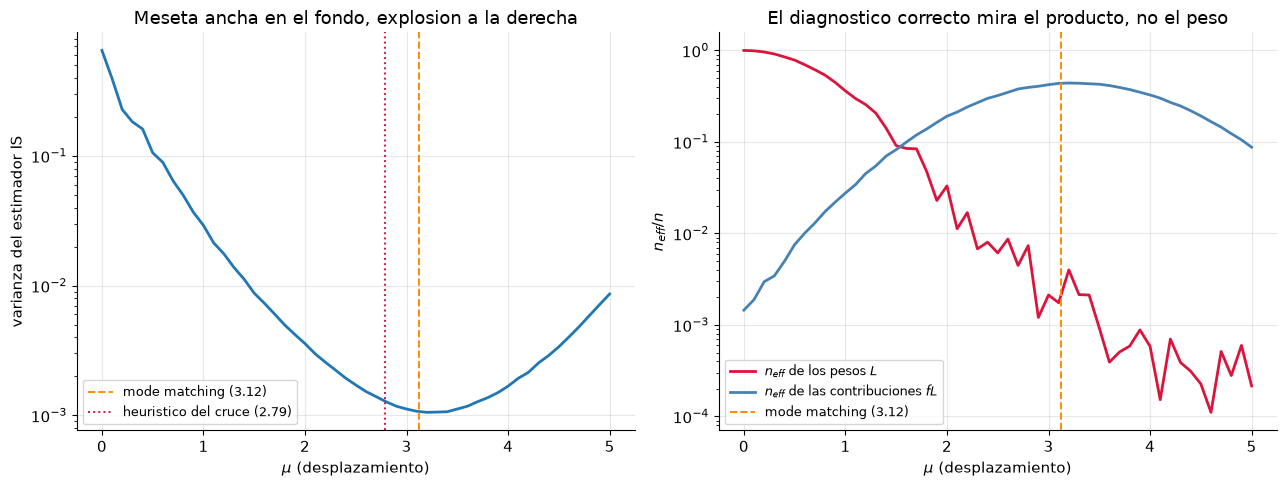

In [3]:
mu_grid = np.linspace(0.0, 5.0, 51)
n_sweep = 40_000
var_sweep, neff_weights, neff_contrib = [], [], []
for i, mu in enumerate(mu_grid):
    rng_sweep = np.random.default_rng(100 + i)
    Z = rng_sweep.standard_normal(n_sweep) + mu
    L = np.exp(-mu * Z + 0.5 * mu**2)
    contrib = call_payoff_otm(Z) * L
    var_sweep.append(contrib.var(ddof=1))
    neff_weights.append(L.sum() ** 2 / (L**2).sum())
    neff_contrib.append(contrib.sum() ** 2 / (contrib**2).sum())
var_sweep = np.array(var_sweep)
neff_weights, neff_contrib = np.array(neff_weights), np.array(neff_contrib)
i_min = int(np.argmin(var_sweep))
mu_argmin = mu_grid[i_min]
mu_argmax_neff = mu_grid[int(np.argmax(neff_contrib))]

print(f"minimo empirico de la varianza en mu = {mu_argmin:.2f}   (mode matching predice {z_mode:.4f})")
print(f"varianza en el minimo = {var_sweep.min():.3e}  |  en mu=0 (crudo) = {var_sweep[0]:.3e}")
print(f"\n{'mu':>6} | {'varianza':>11} | {'n_eff pesos':>12} | {'n_eff contribuciones':>21}")
print("-" * 60)
for mu_show in (0.0, 1.0, 2.0, round(mu_argmin, 1), 4.0, 5.0):
    j = int(np.argmin(np.abs(mu_grid - mu_show)))
    print(f"{mu_grid[j]:>6.2f} | {var_sweep[j]:>11.3e} | {neff_weights[j]:>12,.0f} | {neff_contrib[j]:>21,.0f}")
print(f"\nn_eff de los PESOS: cae monotonamente ({neff_weights[0]:,.0f} -> {neff_weights[-1]:,.0f}); si se leyera")
print("como indicador de salud, rechazaria justamente al mejor estimador.")
print(f"n_eff de las CONTRIBUCIONES: maximo en mu = {mu_argmax_neff:.2f}, practicamente donde la varianza es")
print(f"minima ({mu_argmin:.2f}); y en mu=0 vale {neff_contrib[0]:,.0f} de {n_sweep:,}: el estimador degenerado es el crudo.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(mu_grid, var_sweep, lw=2)
ax.axvline(z_mode, color="darkorange", ls="--", label=f"mode matching ({z_mode:.2f})")
ax.axvline(z_cross, color="crimson", ls=":", label=f"heuristico del cruce ({z_cross:.2f})")
ax.set_yscale("log")
ax.set_xlabel("$\\mu$ (desplazamiento)"); ax.set_ylabel("varianza del estimador IS")
ax.set_title("Meseta ancha en el fondo, explosion a la derecha")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(mu_grid, neff_weights / n_sweep, lw=2, color="crimson", label="$n_{eff}$ de los pesos $L$")
ax.plot(mu_grid, neff_contrib / n_sweep, lw=2, color="steelblue",
        label="$n_{eff}$ de las contribuciones $fL$")
ax.axvline(z_mode, color="darkorange", ls="--", label=f"mode matching ({z_mode:.2f})")
ax.set_yscale("log")
ax.set_xlabel("$\\mu$ (desplazamiento)"); ax.set_ylabel("$n_{eff}/n$")
ax.set_title("El diagnostico correcto mira el producto, no el peso")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Quasi-Monte Carlo: baja discrepancia y scrambling

El Monte Carlo crudo desperdicia esfuerzo: puntos aleatorios se agrupan y dejan huecos, y esos huecos son error. QMC reemplaza el azar por secuencias **deterministas** construidas para minimizar la **discrepancia estrella**
$$
D_n^* = \sup_{B}\ \Big|\frac{\#\{z_i\in B\}}{n} - \text{vol}(B)\Big|,
$$
el máximo desajuste entre la fracción de puntos en una caja anclada al origen y su volumen. La cota de **Koksma-Hlawka** liga error y discrepancia:
$$
\Big|\frac1n\sum f(z_i) - \int f\Big| \ \leq\ V_{HK}(f)\ D_n^* ,
$$
con $V_{HK}$ la variación de Hardy-Krause. Para las secuencias de Sobol $D_n^*=O\big((\log n)^d/n\big)$, es decir **casi $O(1/n)$** frente al $O(n^{-1/2})$ del azar. Dos advertencias sobre esa cota, ambas importantes en la práctica:

1. **Es inútil cuantitativamente.** $V_{HK}(f)$ suele ser infinita para payoffs con kink o salto (un call, un digital), y el factor $(\log n)^d$ es astronómico en dimensión alta. QMC funciona mucho mejor de lo que la cota promete; la cota no explica el éxito.
2. **Determinismo = sin barras de error.** Un solo conjunto QMC da un número sin intervalo de confianza, lo que en pricing es inaceptable.

El **scrambling de Owen** resuelve (2) sin sacrificar (1): aleatoriza los dígitos de la secuencia de modo que cada punto quede uniforme en $[0,1)^d$ — el estimador vuelve a ser insesgado — pero la estructura de baja discrepancia se conserva. Con $R$ réplicas scrambled independientes se estima el error como en Monte Carlo, y de hecho para funciones suaves el scrambling *mejora* la tasa hasta $O(n^{-3/2})$ (Owen 1997).

Medimos entonces el RMSE contra el precio exacto sobre $R=32$ réplicas, para MC y para Sobol scrambled, y ajustamos las pendientes. La teoría predice $-1/2$ para el azar y algo cercano a $-1$ para Sobol en dimensión baja.

Call ATM (d=1), RMSE sobre R=32 replicas contra el precio exacto 10.45058357
       n |     RMSE MC |  RMSE Sobol |    ratio
------------------------------------------------
     256 |   1.000e+00 |   4.756e-02 |    21.0x
    1024 |   3.858e-01 |   9.449e-03 |    40.8x
    4096 |   2.627e-01 |   1.913e-03 |   137.4x
   16384 |   1.027e-01 |   7.842e-04 |   131.0x
   65536 |   4.507e-02 |   1.468e-04 |   307.0x

pendientes: MC = -0.5426 (teoria -1/2) | Sobol scrambled = -1.0135 (casi -1)


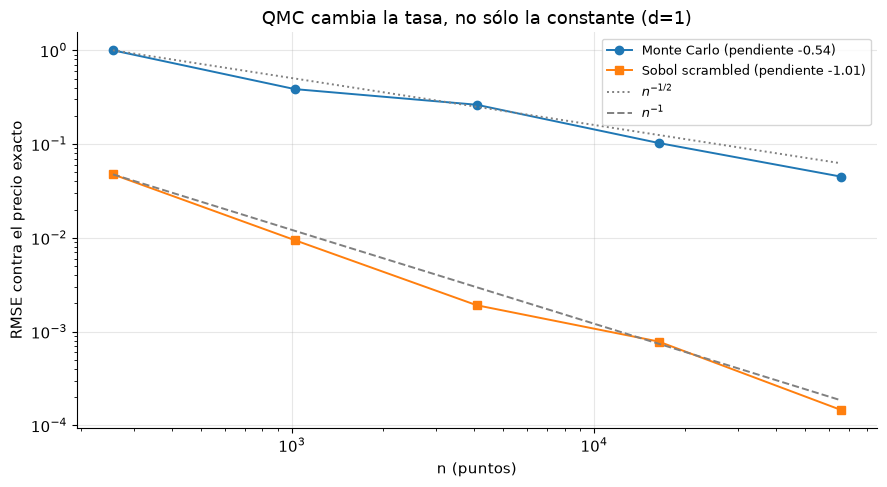

In [4]:
def sobol_normals(n_points, dim, seed):
    '''Scrambled Sobol points mapped to standard normals by the inverse CDF.'''
    return norm.ppf(qmc.Sobol(d=dim, scramble=True, seed=seed).random(n_points))


def call_atm_from_normals(Z):
    return disc * np.maximum(S0 * np.exp(mu_T + sd_T * Z[:, 0]) - K, 0.0)


R_qmc = 32
n_exps = [8, 10, 12, 14, 16]
rmse_mc, rmse_qmc = [], []
for e in n_exps:
    n_pts = 2**e
    est_mc = [call_atm_from_normals(np.random.default_rng(500 + e * 100 + i).standard_normal((n_pts, 1))).mean()
              for i in range(R_qmc)]
    est_qmc = [call_atm_from_normals(sobol_normals(n_pts, 1, 700 + e * 100 + i)).mean() for i in range(R_qmc)]
    rmse_mc.append(np.sqrt(np.mean((np.array(est_mc) - bs_atm) ** 2)))
    rmse_qmc.append(np.sqrt(np.mean((np.array(est_qmc) - bs_atm) ** 2)))
rmse_mc, rmse_qmc = np.array(rmse_mc), np.array(rmse_qmc)
n_vals = np.array([2**e for e in n_exps], dtype=float)

slope_mc = np.polyfit(np.log(n_vals), np.log(rmse_mc), 1)[0]
slope_qmc = np.polyfit(np.log(n_vals), np.log(rmse_qmc), 1)[0]

print(f"Call ATM (d=1), RMSE sobre R={R_qmc} replicas contra el precio exacto {bs_atm:.8f}")
print(f"{'n':>8} | {'RMSE MC':>11} | {'RMSE Sobol':>11} | {'ratio':>8}")
print("-" * 48)
for n_pt, a, b in zip(n_vals, rmse_mc, rmse_qmc):
    print(f"{int(n_pt):>8} | {a:>11.3e} | {b:>11.3e} | {a/b:>7.1f}x")
print(f"\npendientes: MC = {slope_mc:.4f} (teoria -1/2) | Sobol scrambled = {slope_qmc:.4f} (casi -1)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_vals, rmse_mc, "o-", label=f"Monte Carlo (pendiente {slope_mc:.2f})")
ax.plot(n_vals, rmse_qmc, "s-", label=f"Sobol scrambled (pendiente {slope_qmc:.2f})")
ax.plot(n_vals, rmse_mc[0] * (n_vals / n_vals[0]) ** -0.5, ":", color="gray", label="$n^{-1/2}$")
ax.plot(n_vals, rmse_qmc[0] * (n_vals / n_vals[0]) ** -1.0, "--", color="gray", label="$n^{-1}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n (puntos)"); ax.set_ylabel("RMSE contra el precio exacto")
ax.set_title("QMC cambia la tasa, no sólo la constante (d=1)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Demo 4 — dimensión efectiva y el Brownian bridge

En $d=1$ QMC arrasa. La pregunta seria es qué pasa en las dimensiones de un problema real: un LMM con 32 fechas de fixing, un payoff path-dependent monitoreado diario. La cota de Koksma-Hlawka sugiere colapso — el factor $(\log n)^d$ — pero en la práctica QMC sigue ganando, y la explicación es la **dimensión efectiva**: lo que importa no es $d$ sino cuánta varianza vive en las primeras coordenadas y en las interacciones de bajo orden (Caflisch-Morokoff-Owen, 1997). Las secuencias de Sobol son mucho más uniformes en sus primeras dimensiones que en las últimas, así que conviene **construir la trayectoria de modo que las primeras coordenadas expliquen casi todo**.

Eso es exactamente lo que hace el **Brownian bridge**. En vez de generar los incrementos en orden temporal (donde cada coordenada aporta lo mismo), se genera primero $W_T$ con la coordenada 1, luego $W_{T/2}$ condicionado a los extremos con la coordenada 2, luego $W_{T/4}$ y $W_{3T/4}$, y así bisecando:
$$
W_{t_m}\,\big|\,W_{t_l},W_{t_r} \ \sim\ \mathcal{N}\!\left(\frac{(t_r-t_m)W_{t_l}+(t_m-t_l)W_{t_r}}{t_r-t_l},\ \frac{(t_m-t_l)(t_r-t_m)}{t_r-t_l}\right).
$$
La ley del vector $(W_{t_1},\dots,W_{t_d})$ es **idéntica** — no cambia el modelo, sólo qué coordenada de la secuencia alimenta qué parte de la trayectoria — pero la varianza se concentra en las primeras dimensiones, que es donde Sobol es bueno.

Lo probamos en una asiática **geométrica** con $d=32$ fechas, porque ahí tenemos la fórmula cerrada discreta de 3.3 y por lo tanto un precio exacto contra el cual medir RMSE (la aritmética no lo tiene).

Asiatica geometrica d=32, precio exacto = 5.69411372
       n |     MC (secuencial) |  Sobol (secuencial) |      Sobol (bridge)
------------------------------------------------------------------------------
     256 |           4.776e-01 |           1.001e-01 |           3.208e-02
    1024 |           2.254e-01 |           5.118e-02 |           1.110e-02
    4096 |           1.102e-01 |           1.894e-02 |           3.626e-03
   16384 |           6.574e-02 |           6.872e-03 |           1.262e-03
   65536 |           3.322e-02 |           3.778e-03 |           4.944e-04

pendientes: MC (secuencial) = -0.473 | Sobol (secuencial) = -0.618 | Sobol (bridge) = -0.759

Sobol secuencial gana 9x sobre MC en n=2^16; con bridge, 67x. Misma ley, misma secuencia: solo cambia que dimension alimenta que parte de la trayectoria.


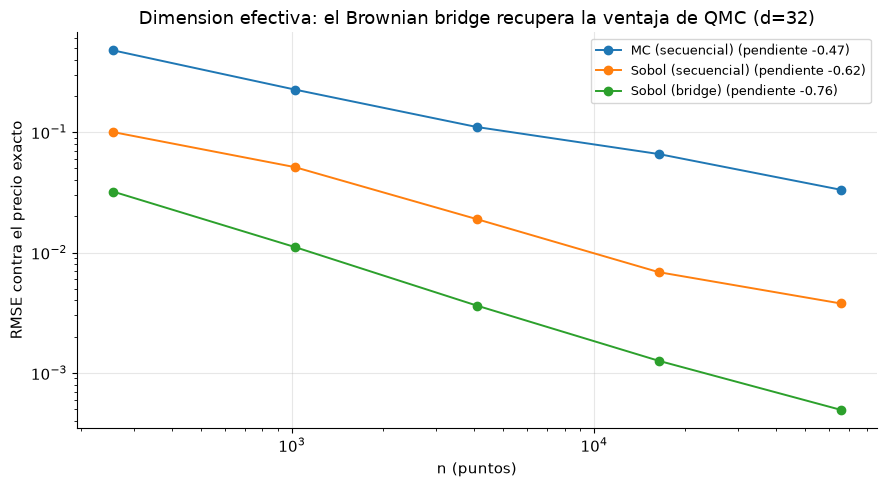

In [5]:
def brownian_bridge_path(Z, T):
    '''Build (W_{t_1},...,W_{t_d}) from standard normals in bridge order (coarse to fine).

    Column 0 of Z sets W_T, the next columns fill in the midpoints by bisection, so the first
    Sobol dimensions carry most of the variance. The law of the output is identical to the
    sequential construction.
    '''
    n_pts, d = Z.shape
    times = np.arange(1, d + 1) * (T / d)
    W = np.zeros((n_pts, d))
    W[:, d - 1] = np.sqrt(T) * Z[:, 0]
    col = 1
    queue = deque([(-1, d - 1)])   # (indice izquierdo, indice derecho); -1 representa t=0, W=0
    while queue:
        left, right = queue.popleft()
        if right - left < 2:
            continue
        mid = (left + right) // 2
        t_l = times[left] if left >= 0 else 0.0
        W_l = W[:, left] if left >= 0 else 0.0
        t_m, t_r = times[mid], times[right]
        mean = ((t_r - t_m) * W_l + (t_m - t_l) * W[:, right]) / (t_r - t_l)
        std = np.sqrt((t_m - t_l) * (t_r - t_m) / (t_r - t_l))
        W[:, mid] = mean + std * Z[:, col]
        col += 1
        queue.append((left, mid)); queue.append((mid, right))
    return W


def geometric_asian_discrete(S0, K, r, q, sigma, T, m):
    '''Exact price of the discretely-monitored geometric Asian call (3.3 §6.1b).'''
    nu = r - q - 0.5 * sigma**2
    dt = T / m
    mean_log = np.log(S0) + nu * dt * (m + 1) / 2.0
    var_log = sigma**2 * dt * (m + 1) * (2 * m + 1) / (6.0 * m)
    s = np.sqrt(var_log)
    F = np.exp(mean_log + 0.5 * var_log)
    d1 = (np.log(F / K) + 0.5 * s**2) / s
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d1 - s))


d_asian = 32
ref_asian = geometric_asian_discrete(S0, K, r, q, sigma, T, d_asian)


def geo_asian_from_normals(Z, bridge):
    d = Z.shape[1]
    dt_d = T / d
    W = brownian_bridge_path(Z, T) if bridge else np.cumsum(np.sqrt(dt_d) * Z, axis=1)
    times = np.arange(1, d + 1) * dt_d
    log_S = np.log(S0) + (r - q - 0.5 * sigma**2) * times + sigma * W
    return disc * np.maximum(np.exp(log_S.mean(axis=1)) - K, 0.0)


rmse_by_method = {"MC (secuencial)": [], "Sobol (secuencial)": [], "Sobol (bridge)": []}
for e in n_exps:
    n_pts = 2**e
    ests = {k: [] for k in rmse_by_method}
    for i in range(R_qmc):
        Z_mc = np.random.default_rng(900 + e * 100 + i).standard_normal((n_pts, d_asian))
        Z_sb = sobol_normals(n_pts, d_asian, 1100 + e * 100 + i)
        ests["MC (secuencial)"].append(geo_asian_from_normals(Z_mc, False).mean())
        ests["Sobol (secuencial)"].append(geo_asian_from_normals(Z_sb, False).mean())
        ests["Sobol (bridge)"].append(geo_asian_from_normals(Z_sb, True).mean())
    for k, v in ests.items():
        rmse_by_method[k].append(np.sqrt(np.mean((np.array(v) - ref_asian) ** 2)))

print(f"Asiatica geometrica d={d_asian}, precio exacto = {ref_asian:.8f}")
print(f"{'n':>8} | " + " | ".join(f"{k:>19}" for k in rmse_by_method))
print("-" * 78)
for j, n_pt in enumerate(n_vals):
    print(f"{int(n_pt):>8} | " + " | ".join(f"{rmse_by_method[k][j]:>19.3e}" for k in rmse_by_method))
slopes_asian = {k: np.polyfit(np.log(n_vals), np.log(v), 1)[0] for k, v in rmse_by_method.items()}
print("\npendientes: " + " | ".join(f"{k} = {v:.3f}" for k, v in slopes_asian.items()))
print(f"\nSobol secuencial gana {rmse_by_method['MC (secuencial)'][-1]/rmse_by_method['Sobol (secuencial)'][-1]:.0f}x "
      f"sobre MC en n=2^16; con bridge, "
      f"{rmse_by_method['MC (secuencial)'][-1]/rmse_by_method['Sobol (bridge)'][-1]:.0f}x. "
      f"Misma ley, misma secuencia: solo cambia que dimension alimenta que parte de la trayectoria.")

fig, ax = plt.subplots(figsize=(9, 5))
for k, v in rmse_by_method.items():
    ax.plot(n_vals, v, "o-", label=f"{k} (pendiente {slopes_asian[k]:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n (puntos)"); ax.set_ylabel("RMSE contra el precio exacto")
ax.set_title(f"Dimension efectiva: el Brownian bridge recupera la ventaja de QMC (d={d_asian})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Validación

1. **Importance sampling**: los dos estimadores IS dentro de 3 SE del precio exacto de Black-Scholes; reducción de varianza $>20\times$ para ambos y $>500\times$ para el de mode matching; el mínimo empírico del barrido dentro de $\pm0.3$ del $\mu$ que predice el mode matching; el heurístico del cruce estrictamente peor que el mode matching (la afirmación de la §1 de que no son lo mismo); y el máximo de $n_{\text{eff}}^{fL}$ dentro de $\pm0.3$ del mínimo de la varianza — que es la afirmación de la §2 sobre cuál de los dos diagnósticos sirve.
2. **QMC en $d=1$**: pendiente de MC en $[-0.60,-0.40]$ y de Sobol scrambled $<-0.90$; ganancia $>100\times$ en $n=2^{16}$; media de las réplicas Sobol dentro de 3 SE (calculado con la dispersión **entre réplicas**, la única medición válida, como en 4.2 §4).
3. **Dimensión y bridge**: en $d=32$ la pendiente de Sobol secuencial se degrada a $[-0.80,-0.50]$ — la evidencia de que la dimensión sí cobra — mientras que con bridge mejora a $<-0.75$, y el bridge domina al secuencial en **todos** los $n$ probados.

In [6]:
# 1. Importance sampling
for label, (mu, mean, se, var) in is_results.items():
    z = abs(mean - bs_otm) / se
    red = var_plain / var
    print(f"{label:>22}: mu={mu:.4f} precio={mean:.6f} |diff|/SE={z:.3f} reduccion={red:.1f}x")
    assert z <= 3.0
    assert red > 20.0
assert var_plain / is_results["IS (mode matching)"][3] > 500.0
assert is_results["IS (mode matching)"][3] < is_results["IS (cruce)"][3], \
    "el mode matching debe tener menor varianza que el heuristico del cruce"
print(f"minimo del barrido = {mu_argmin:.2f} vs mode matching {z_mode:.4f} "
      f"(|diff| <= 0.3? {abs(mu_argmin - z_mode) <= 0.3})")
assert abs(mu_argmin - z_mode) <= 0.3
print(f"maximo de n_eff(contribuciones) en mu = {mu_argmax_neff:.2f} vs minimo de varianza en {mu_argmin:.2f} "
      f"(|diff| <= 0.3? {abs(mu_argmax_neff - mu_argmin) <= 0.3})")
assert abs(mu_argmax_neff - mu_argmin) <= 0.3
assert neff_weights[-1] < neff_weights[0] and neff_contrib[0] < neff_contrib[i_min], \
    "los pesos degeneran con mu; las contribuciones son las que mejoran"

# 2. QMC en d=1
print(f"\npendiente MC = {slope_mc:.4f} | pendiente Sobol = {slope_qmc:.4f}")
assert -0.60 <= slope_mc <= -0.40
assert slope_qmc < -0.90
gain_d1 = rmse_mc[-1] / rmse_qmc[-1]
print(f"ganancia de Sobol en n=2^16: {gain_d1:.0f}x (>100? {gain_d1 > 100})")
assert gain_d1 > 100.0

# 3. Dimension y Brownian bridge
print(f"\nd={d_asian}: " + " | ".join(f"{k} = {v:.3f}" for k, v in slopes_asian.items()))
assert -0.80 <= slopes_asian["Sobol (secuencial)"] <= -0.50
assert slopes_asian["Sobol (bridge)"] < -0.75
assert all(b < s for b, s in zip(rmse_by_method["Sobol (bridge)"], rmse_by_method["Sobol (secuencial)"])), \
    "el bridge debe dominar al orden secuencial en todos los n"
print("el bridge domina al orden secuencial en todos los n probados")

print()
print("Validacion completa: 3/3 dentro de tolerancia.")

            IS (cruce): mu=2.7889 precio=0.028695 |diff|/SE=0.459 reduccion=622.6x
    IS (mode matching): mu=3.1202 precio=0.028697 |diff|/SE=0.519 reduccion=746.4x
minimo del barrido = 3.20 vs mode matching 3.1202 (|diff| <= 0.3? True)
maximo de n_eff(contribuciones) en mu = 3.20 vs minimo de varianza en 3.20 (|diff| <= 0.3? True)

pendiente MC = -0.5426 | pendiente Sobol = -1.0135
ganancia de Sobol en n=2^16: 307x (>100? True)

d=32: MC (secuencial) = -0.473 | Sobol (secuencial) = -0.618 | Sobol (bridge) = -0.759
el bridge domina al orden secuencial en todos los n probados

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*, Springer, caps. 4.6 (importance sampling) y 5 (QMC).
- Glasserman, P., Heidelberger, P. & Shahabuddin, P. (1999). *Asymptotically Optimal Importance Sampling and Stratification for Pricing Path-Dependent Options*. Mathematical Finance, 9(2), 117-152.
- Owen, A.B. (1997). *Scrambled Net Variance for Integrals of Smooth Functions*. Annals of Statistics, 25(4), 1541-1562.
- Sobol', I.M. (1967). *On the Distribution of Points in a Cube and the Approximate Evaluation of Integrals*. USSR Comp. Math. and Math. Physics, 7(4), 86-112.
- Caflisch, R.E., Morokoff, W. & Owen, A.B. (1997). *Valuation of Mortgage-Backed Securities Using Brownian Bridges to Reduce Effective Dimension*. Journal of Computational Finance, 1(1), 27-46.
- Niederreiter, H. (1992). *Random Number Generation and Quasi-Monte Carlo Methods*, SIAM (discrepancia, Koksma-Hlawka).